In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("List of Countries by Sugarcane Production.csv")
df.head(10)

,Unnamed: 0,Country,Continent,Production (Tons),Production per Person (Kg),Acreage (Hectare),Yield (Kg / Hectare)
0,0,Brazil,South America,768.678.382,"3.668,531",10.226.205,"75.167,5"
1,1,India,Asia,348.448.000,260721,4.950.000,"70.393,5"
2,2,China,Asia,123.059.739,88287,1.675.215,"73.459,1"
3,3,Thailand,Asia,87.468.496,"1.264,303",1.336.575,"65.442,2"
4,4,Pakistan,Asia,65.450.704,324219,1.130.820,57.879
5,5,Mexico,North America,56.446.821,452524,781.054,72.27
6,6,Colombia,South America,36.951.213,740075,416.626,"88.691,5"
7,7,Australia,Oceania,34.403.004,"1.373,406",447.204,"76.929,1"
8,8,Guatemala,North America,33.533.403,"1.938,114",259.85,"129.049,3"
9,9,United States of America,North America,29.926.210,91304,370.53,80.766


In [3]:
df.shape

(103, 7)

In [4]:
df["Production (Tons)"] = df["Production (Tons)"].str.replace(".","")
df["Production per Person (Kg)"] = df["Production per Person (Kg)"].str.replace(".","").str.replace(",",".")
df["Acreage (Hectare)"] = df["Acreage (Hectare)"].str.replace(".","")
df["Yield (Kg / Hectare)"]= df["Yield (Kg / Hectare)"].str.replace(".","").str.replace(",",".")

In [5]:
df.rename(columns = {"Production per Person (Kg)" : "Production_per_Person_(Kg)"} , inplace = True)
df.rename(columns = {"Production (Tons)" : "Production_(Tons)"} , inplace = True)
df.rename(columns = {"Acreage (Hectare)" : "Acreage_(Hectare)"} , inplace = True)
df.rename(columns = {"Yield (Kg / Hectare)" : "Yield_(Kg/Hectare)"} , inplace = True)

In [6]:
df.head()

,Unnamed: 0,Country,Continent,Production_(Tons),Production_per_Person_(Kg),Acreage_(Hectare),Yield_(Kg/Hectare)
0,0,Brazil,South America,768678382,3668.531,10226205,75167.5
1,1,India,Asia,348448000,260721,4950000,70393.5
2,2,China,Asia,123059739,88287,1675215,73459.1
3,3,Thailand,Asia,87468496,1264.303,1336575,65442.2
4,4,Pakistan,Asia,65450704,324219,1130820,57879


In [7]:
df.isnull().sum()

Unnamed: 0                    0
Country                       0
Continent                     0
Production_(Tons)             0
Production_per_Person_(Kg)    0
Acreage_(Hectare)             1
Yield_(Kg/Hectare)            1
dtype: int64

In [8]:
df[df["Acreage_(Hectare)"].isnull()]

,Unnamed: 0,Country,Continent,Production_(Tons),Production_per_Person_(Kg),Acreage_(Hectare),Yield_(Kg/Hectare)
99,99,Djibouti,Africa,53,51,NaN,NaN


In [9]:
df = df.dropna().reset_index()

In [10]:
df.tail(10)

,index,Unnamed: 0,Country,Continent,Production_(Tons),Production_per_Person_(Kg),Acreage_(Hectare),Yield_(Kg/Hectare)
92,92,92,Portugal,Europe,5429,528,62,88274.4
93,93,93,Antigua and Barbuda,North America,5365,6217,83,64638.6
94,94,94,Dominica,North America,4855,68099,244,19914.4
95,95,95,Oman,Asia,1186,237,51,23432.2
96,96,96,Yemen,Asia,500,17,50,10
97,97,97,Spain,Europe,394,8,9,43596.5
98,98,98,Lebanon,Asia,97,16,3,28386.4
99,100,100,Singapore,Asia,50,9,2,25
100,101,101,Samoa,Oceania,12,6,1,11949.8
101,102,102,Syria,Asia,1,0,0,83034.2


In [11]:
df.drop(["index" , "Unnamed: 0"], axis = 1,inplace = True)

In [12]:
df.head()

,Country,Continent,Production_(Tons),Production_per_Person_(Kg),Acreage_(Hectare),Yield_(Kg/Hectare)
0,Brazil,South America,768678382,3668.531,10226205,75167.5
1,India,Asia,348448000,260721,4950000,70393.5
2,China,Asia,123059739,88287,1675215,73459.1
3,Thailand,Asia,87468496,1264.303,1336575,65442.2
4,Pakistan,Asia,65450704,324219,1130820,57879


In [13]:
df.dtypes

Country                       object
Continent                     object
Production_(Tons)             object
Production_per_Person_(Kg)    object
Acreage_(Hectare)             object
Yield_(Kg/Hectare)            object
dtype: object

In [14]:
df["Production_(Tons)"] = df["Production_(Tons)"].astype(float)
df["Production_per_Person_(Kg)"] = df["Production_per_Person_(Kg)"].astype(float)
df["Acreage_(Hectare)"] = df["Acreage_(Hectare)"].astype(float)
df["Yield_(Kg/Hectare)"] = df["Yield_(Kg/Hectare)"].astype(float)

In [15]:
df.dtypes

Country                        object
Continent                      object
Production_(Tons)             float64
Production_per_Person_(Kg)    float64
Acreage_(Hectare)             float64
Yield_(Kg/Hectare)            float64
dtype: object

In [16]:
df.nunique()

Country                       102
Continent                       6
Production_(Tons)             102
Production_per_Person_(Kg)    101
Acreage_(Hectare)             101
Yield_(Kg/Hectare)            102
dtype: int64

In [17]:
df["Continent"].value_counts()

Continent
Africa           38
Asia             25
North America    22
South America    11
Oceania           4
Europe            2
Name: count, dtype: int64

<Axes: xlabel='Continent'>

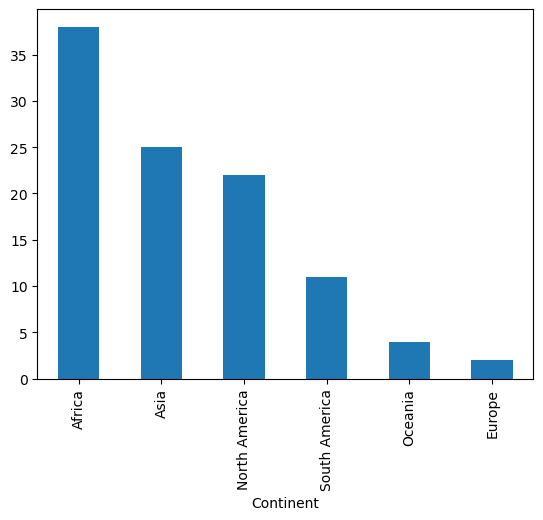

In [18]:
df["Continent"].value_counts().plot(kind = "bar")

C:\Users\Dell\AppData\Local\Temp\ipykernel_11940\1208535691.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df["Production_(Tons)"])
C:\Users\Dell\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\Dell\AppData\Local\Temp\ipykernel_11940\1208535691.py:5: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar fle

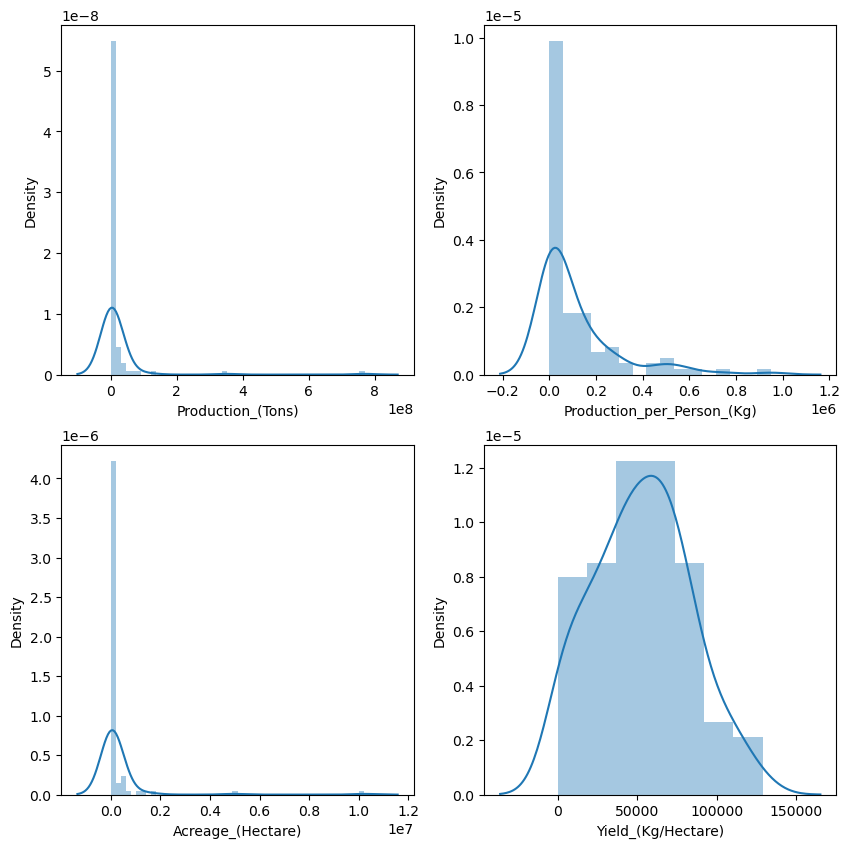

In [19]:
plt.figure(figsize = (10,10))
plt.subplot(2,2,1)
sns.distplot(df["Production_(Tons)"])
plt.subplot(2,2,2)
sns.distplot(df["Production_per_Person_(Kg)"])
plt.subplot(2,2,3)
sns.distplot(df["Acreage_(Hectare)"])
plt.subplot(2,2,4)
sns.distplot(df["Yield_(Kg/Hectare)"])
plt.show()

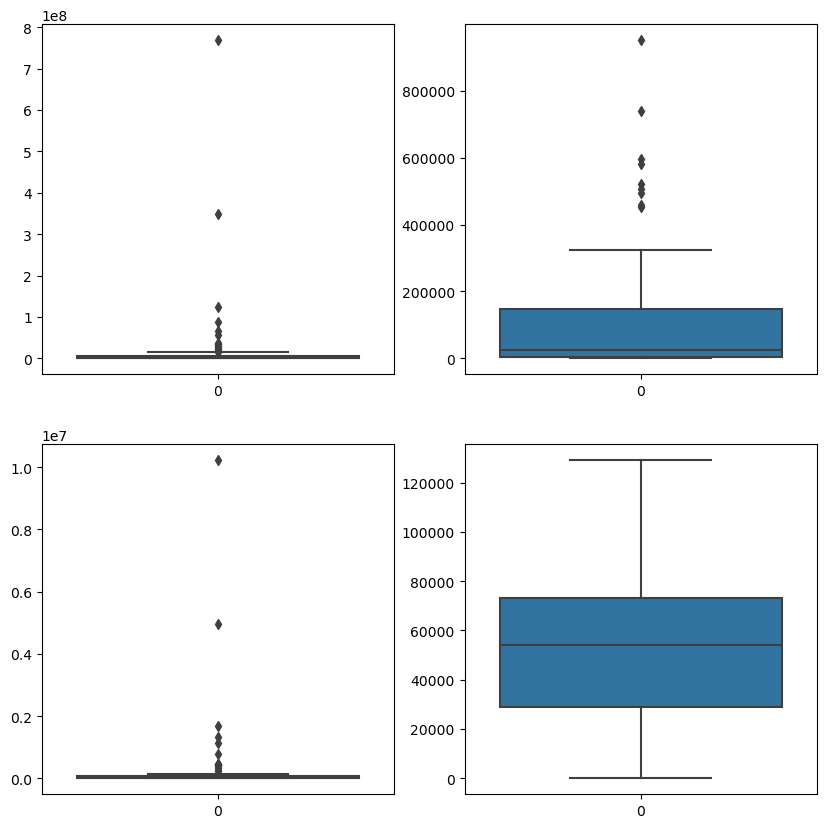

In [20]:
plt.figure(figsize = (10,10))
plt.subplot(2,2,1)
sns.boxplot(df["Production_(Tons)"])
plt.subplot(2,2,2)
sns.boxplot(df["Production_per_Person_(Kg)"])
plt.subplot(2,2,3)
sns.boxplot(df["Acreage_(Hectare)"])
plt.subplot(2,2,4)
sns.boxplot(df["Yield_(Kg/Hectare)"])
plt.show()

In [21]:
df.describe()

,Production_(Tons),Production_per_Person_(Kg),Acreage_(Hectare),Yield_(Kg/Hectare)
count,1.020000e+02,102.000000,1.020000e+02,102.000000
mean,1.850372e+07,112952.435755,2.498981e+05,52628.078431
std,8.419149e+07,176651.341929,1.137003e+06,30504.676683
min,1.000000e+00,0.000000,0.000000e+00,10.000000
25%,6.251875e+04,3671.910000,1.104000e+03,29072.025000
50%,1.440044e+06,25572.500000,1.655800e+04,54108.950000
75%,6.426824e+06,146384.750000,8.047400e+04,73282.700000
max,7.686784e+08,951087.000000,1.022620e+07,129049.300000


In [22]:
df.head()

,Country,Continent,Production_(Tons),Production_per_Person_(Kg),Acreage_(Hectare),Yield_(Kg/Hectare)
0,Brazil,South America,768678382.0,3668.531,10226205.0,75167.5
1,India,Asia,348448000.0,260721.000,4950000.0,70393.5
2,China,Asia,123059739.0,88287.000,1675215.0,73459.1
3,Thailand,Asia,87468496.0,1264.303,1336575.0,65442.2
4,Pakistan,Asia,65450704.0,324219.000,1130820.0,57879.0


In [23]:
df_new = df[["Country" , "Production_(Tons)"]].set_index("Country")

In [24]:
df_new

,Production_(Tons)
Country,
Brazil,768678382.0
India,348448000.0
China,123059739.0
Thailand,87468496.0
Pakistan,65450704.0
...,...
Spain,394.0
Lebanon,97.0
Singapore,50.0


In [27]:
df_new["Production_(Tons)_percent"] = df_new["Production_(Tons)"]*100/df_new["Production_(Tons)"].sum()

In [28]:
df_new

,Production_(Tons),Production_(Tons)_percentage,Production_(Tons)_percent
Country,,,
Brazil,768678382.0,NaN,4.072729e+01
India,348448000.0,NaN,1.846200e+01
China,123059739.0,NaN,6.520138e+00
Thailand,87468496.0,NaN,4.634389e+00
Pakistan,65450704.0,NaN,3.467809e+00
...,...,...,...
Spain,394.0,NaN,2.087551e-05
Lebanon,97.0,NaN,5.139401e-06
Singapore,50.0,NaN,2.649176e-06


In [33]:
df_new.drop("Production_(Tons)_percentage",axis = 1,inplace =True)

In [34]:
df_new

,Production_(Tons),Production_(Tons)_percent
Country,,
Brazil,768678382.0,4.072729e+01
India,348448000.0,1.846200e+01
China,123059739.0,6.520138e+00
Thailand,87468496.0,4.634389e+00
Pakistan,65450704.0,3.467809e+00
...,...,...
Spain,394.0,2.087551e-05
Lebanon,97.0,5.139401e-06
Singapore,50.0,2.649176e-06


Which country produces maximum sugarcane?

<Axes: ylabel='Production_(Tons)_percent'>

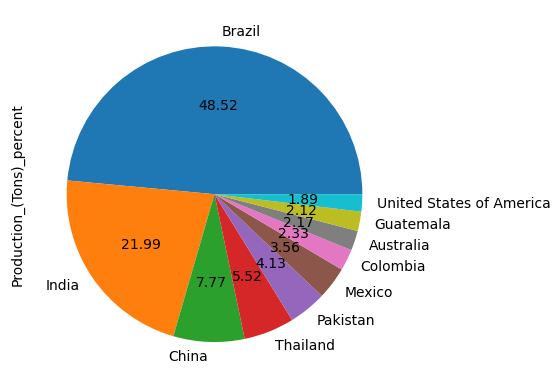

In [37]:
df_new["Production_(Tons)_percent"].head(10).plot(kind = "pie" , autopct = "%.2f")

<Axes: xlabel='Country'>

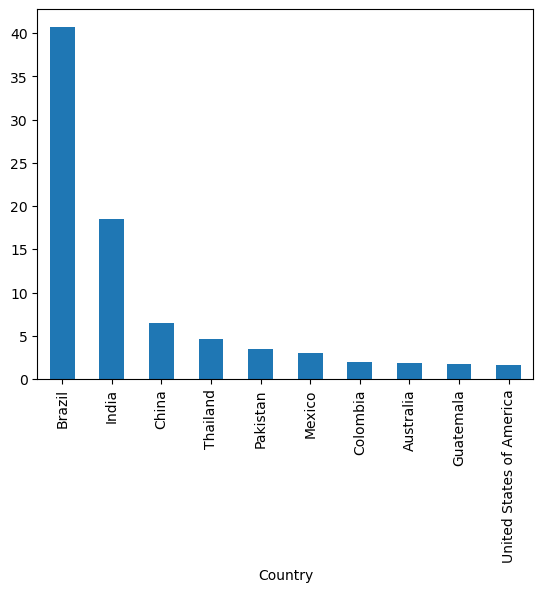

In [36]:
df_new["Production_(Tons)_percent"].head(10).plot(kind = "bar")

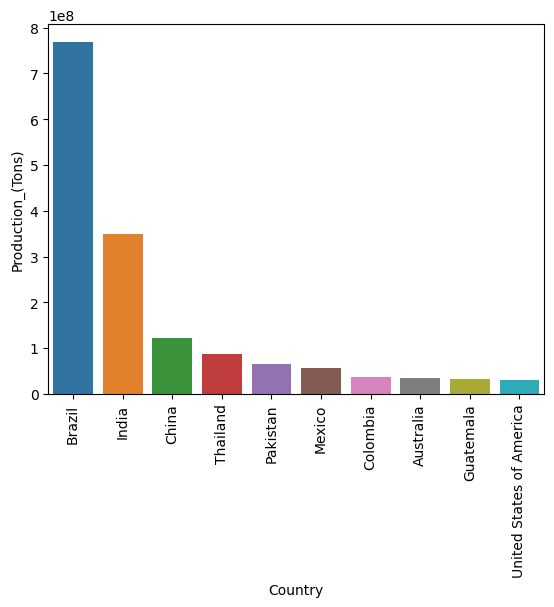

In [41]:
ax = sns.barplot(data = df.head(10) ,x = "Country" , y = "Production_(Tons)")
ax.set_xticklabels(ax.get_xticklabels(), rotation = 90)
plt.show()

In [44]:
df.head()

,Country,Continent,Production_(Tons),Production_per_Person_(Kg),Acreage_(Hectare),Yield_(Kg/Hectare)
0,Brazil,South America,768678382.0,3668.531,10226205.0,75167.5
1,India,Asia,348448000.0,260721.000,4950000.0,70393.5
2,China,Asia,123059739.0,88287.000,1675215.0,73459.1
3,Thailand,Asia,87468496.0,1264.303,1336575.0,65442.2
4,Pakistan,Asia,65450704.0,324219.000,1130820.0,57879.0


Which country has highest land?

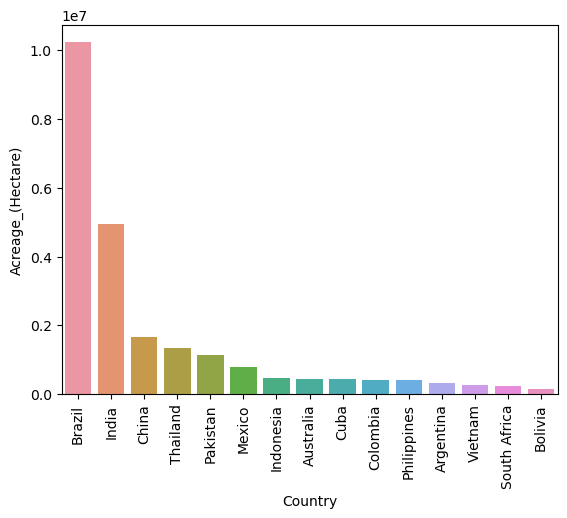

In [43]:
df_acr = df.sort_values("Acreage_(Hectare)", ascending = False).head(15)
ax = sns.barplot(data = df_acr,  x= "Country", y = "Acreage_(Hectare)")
ax.set_xticklabels(ax.get_xticklabels(),rotation =90)
plt.show()

Which country has highest yield per hectare?

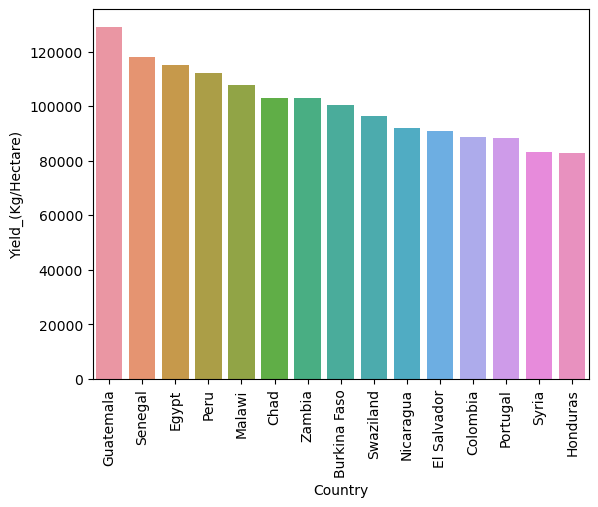

In [45]:
df_yield = df.sort_values("Yield_(Kg/Hectare)", ascending = False).head(15)
ax = sns.barplot(data = df_yield,  x= "Country", y = "Yield_(Kg/Hectare)")
ax.set_xticklabels(ax.get_xticklabels(),rotation =90)
plt.show() 

Which country has highest production

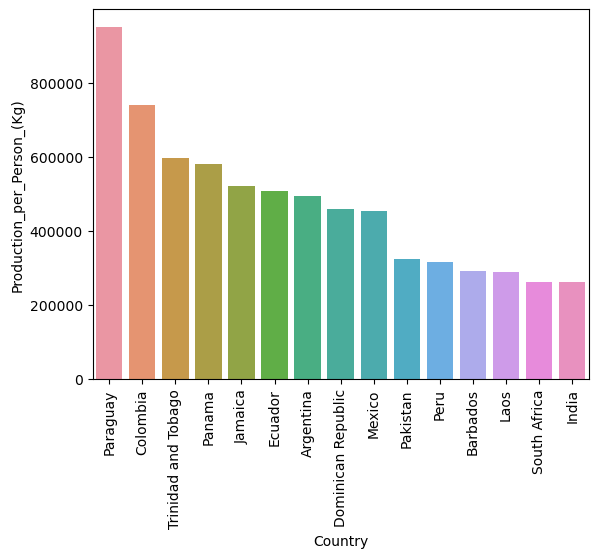

In [46]:
df_prod = df.sort_values("Production_per_Person_(Kg)", ascending = False).head(15)
ax = sns.barplot(data = df_prod,  x= "Country", y = "Production_per_Person_(Kg)")
ax.set_xticklabels(ax.get_xticklabels(),rotation =90)
plt.show() 

Correllation

In [52]:
numeric_df = df.select_dtypes(include=[float, int])

# Calculate the correlation matrix on the numeric data only
correlation_matrix = numeric_df.corr()

# Display the correlation matrix
correlation_matrix

,Production_(Tons),Production_per_Person_(Kg),Acreage_(Hectare),Yield_(Kg/Hectare)
Production_(Tons),1.000000,0.015000,0.997550,0.132812
Production_per_Person_(Kg),0.015000,1.000000,0.012557,0.017999
Acreage_(Hectare),0.997550,0.012557,1.000000,0.113433
Yield_(Kg/Hectare),0.132812,0.017999,0.113433,1.000000


<Axes: >

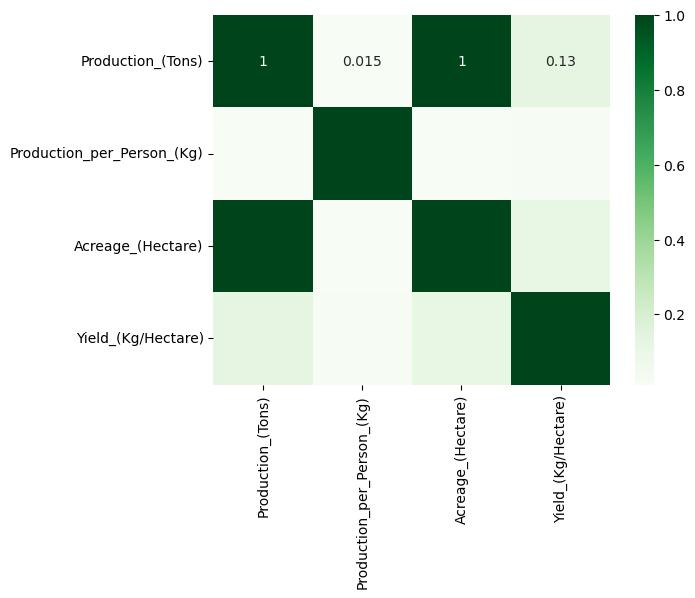

In [57]:
sns.heatmap(correlation_matrix, annot = True, cmap="Greens")

<Axes: xlabel='Acreage_(Hectare)', ylabel='Production_(Tons)'>

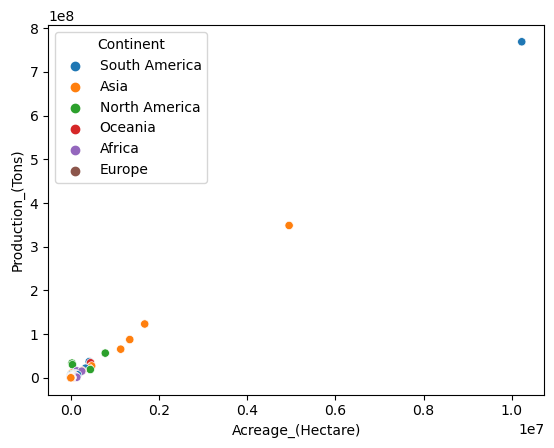

In [59]:
sns.scatterplot(data = df , x = "Acreage_(Hectare)",y = "Production_(Tons)", hue = "Continent" )

Do countries which yield more sugarcane per hectare produces more sugarcane in total?

<Axes: xlabel='Yield_(Kg/Hectare)', ylabel='Production_(Tons)'>

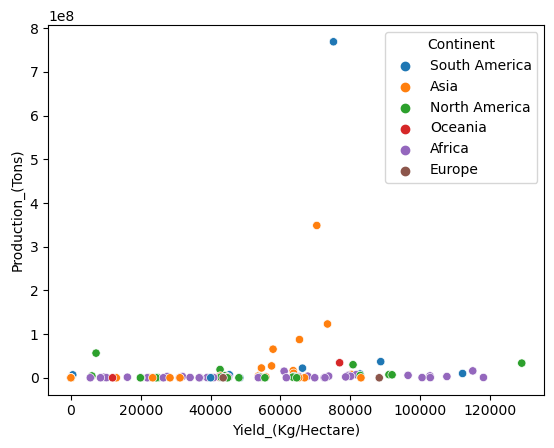

In [60]:
sns.scatterplot(data = df, x = "Yield_(Kg/Hectare)" , y = "Production_(Tons)", hue = "Continent")

In [61]:
df.head()

,Country,Continent,Production_(Tons),Production_per_Person_(Kg),Acreage_(Hectare),Yield_(Kg/Hectare)
0,Brazil,South America,768678382.0,3668.531,10226205.0,75167.5
1,India,Asia,348448000.0,260721.000,4950000.0,70393.5
2,China,Asia,123059739.0,88287.000,1675215.0,73459.1
3,Thailand,Asia,87468496.0,1264.303,1336575.0,65442.2
4,Pakistan,Asia,65450704.0,324219.000,1130820.0,57879.0


In [62]:
df_continent = df.groupby("Continent").sum()

In [63]:
df_continent["number_of_countries"] = df.groupby("Continent").count()["Country"]

In [64]:
df_continent

,Country,Production_(Tons),Production_per_Person_(Kg),Acreage_(Hectare),Yield_(Kg/Hectare),number_of_countries
Continent,,,,,,
Africa,EgyptSouth AfricaKenyaSwazilandSudanZambiaMaur...,89681472.0,2332636.293,1439089.0,2142107.5,38
Asia,IndiaChinaThailandPakistanIndonesiaPhilippines...,721930425.0,1857769.303,10608319.0,1171871.4,25
Europe,PortugalSpain,5823.0,536.000,71.0,131870.9,2
North America,MexicoGuatemalaUnited States of AmericaCubaEl ...,173995947.0,3796081.508,1581983.0,1082602.4,22
Oceania,AustraliaFijiPapua New GuineaSamoa,36177574.0,28593.605,490909.0,162419.1,4
South America,BrazilColombiaArgentinaPeruEcuadorBoliviaParag...,865588126.0,3505531.738,11369236.0,677192.7,11


<Axes: xlabel='Continent'>

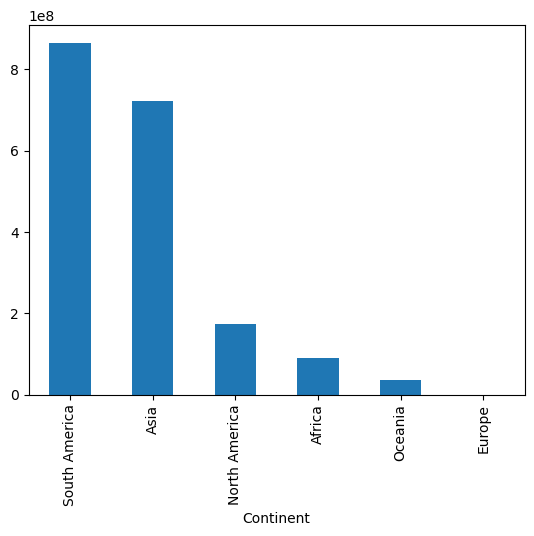

In [65]:
df_continent["Production_(Tons)"].sort_values(ascending =  False).plot(kind = "bar")

C:\Users\Dell\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\Dell\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


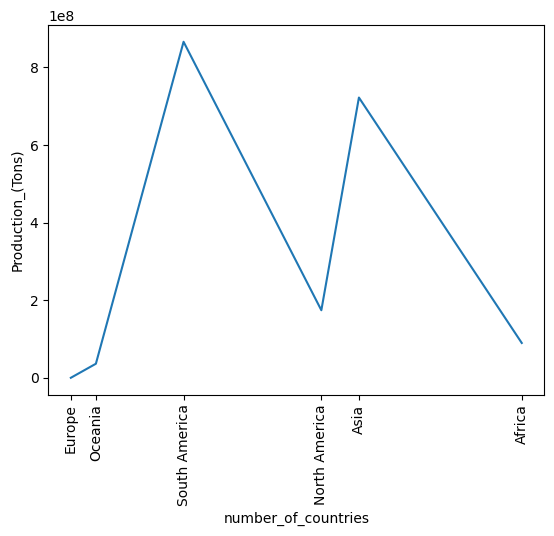

In [66]:
continent_names = df_continent.index.to_list()
sns.lineplot(data = df_continent,x = "number_of_countries", y= "Production_(Tons)" )
plt.xticks(df_continent["number_of_countries"], continent_names, rotation =90)
plt.show()

C:\Users\Dell\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\Dell\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


<Axes: xlabel='Acreage_(Hectare)', ylabel='Production_(Tons)'>

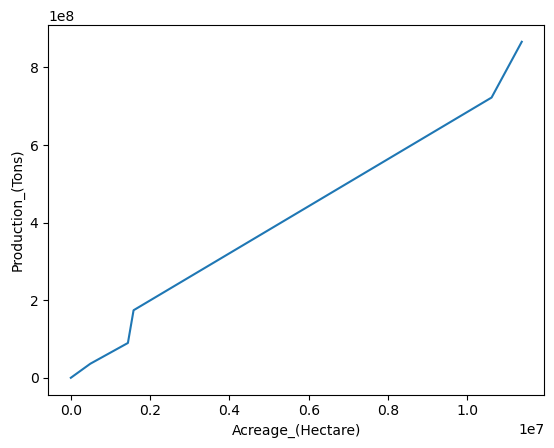

In [67]:
sns.lineplot(data = df_continent,x = "Acreage_(Hectare)", y= "Production_(Tons)" )

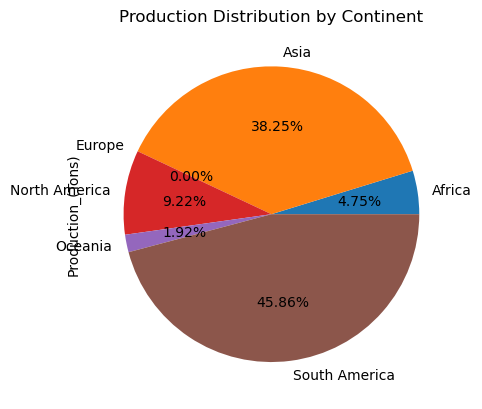

In [68]:
df_continent["Production_(Tons)"].plot(kind = "pie", autopct = "%.2f%%")
plt.title('Production Distribution by Continent')
plt.show()

In [70]:
#df_continent.corr()
numeric_df = df_continent.select_dtypes(include=[float, int])

# Calculate the correlation matrix on the numeric data only
correlation_matrix = numeric_df.corr()

# Display the correlation matrix
correlation_matrix

,Production_(Tons),Production_per_Person_(Kg),Acreage_(Hectare),Yield_(Kg/Hectare),number_of_countries
Production_(Tons),1.000000,0.522211,0.994897,0.091201,0.109244
Production_per_Person_(Kg),0.522211,1.000000,0.463215,0.542961,0.540086
Acreage_(Hectare),0.994897,0.463215,1.000000,0.111166,0.132817
Yield_(Kg/Hectare),0.091201,0.542961,0.111166,1.000000,0.989712
number_of_countries,0.109244,0.540086,0.132817,0.989712,1.000000
